## LSTM Model

In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the spreadsheet
file_path = r"C:\Users\anngu\Documents\Code\SIT374\Alert_system\New AI spreadsheet - Sheet1.csv"  
df = pd.read_csv(file_path)  

### Cleaning number columns

In [17]:
import re
import ast
import pandas as pd
import numpy as np

# --- 1. Clean heartRate: Extract numbers from "65 bpm" ---
df['heart_rate'] = df['heartRate'].str.extract(r'(\d+)').astype(float)

# --- 2. Clean spo2: Extract numbers from "97%" ---
df['spo2_value'] = df['spo2'].str.extract(r'(\d+)').astype(float)

# --- 3. Clean temperature: Extract numbers from "36.5 °C" ---
# Handle the special character (Â°C might be in your data)
df['temp_clean'] = df['temperature'].str.replace('Â°C', '°C') # Fix encoding if needed
df['temperature_value'] = df['temp_clean'].str.extract(r'(\d+\.\d+|\d+)').astype(float)

# --- 4. Clean bloodPressure: Split "114/71 mmHg" into two columns ---
bp_split = df['bloodPressure'].str.extract(r'(\d+)\/(\d+)')
df['bp_systolic'] = bp_split[0].astype(float)
df['bp_diastolic'] = bp_split[1].astype(float)

# --- 5. Create a Target Label from the 'state' column ---
# The 'state' column has many missing values (NaN). Let's see the unique values.
print("Unique states in the data:")
print(df['state'].unique())

# We can infer the state from the behaviourTags or other columns if needed.
# For now, let's assume the missing states are 'normal' and create a label.
# 0 = normal, 1 = uncomfortable, 2 = sick
state_mapping = {'normal': 0, 'uncomfortable': 1, 'sick': 2}
df['state_label'] = df['state'].map(state_mapping)

# Fill the missing state_label with 0 (assuming they are normal)
df['state_label'] = df['state_label'].fillna(0)
print("\nValue counts for state_label:")
print(df['state_label'].value_counts())

# -----------------------------
# Make Feature Set for the LSTM
# -----------------------------

# List all the numerical features we have
feature_columns = [
    'heart_rate', 'spo2_value', 'temperature_value',
    'bp_systolic', 'bp_diastolic',
    'stepsTaken', 'calorieIntake', 'sleepHours',
    'waterIntakeMl', 'exerciseMinutes', 'bathroomVisits'
]

# Create our feature matrix X
X = df[feature_columns]

# Handle any remaining missing values (use mean)
X = X.fillna(X.mean())

# Our target label y (for supervised learning)
y = df['state_label']

print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)

Unique states in the data:
[nan 'normal' 'uncomfortable' 'sick']

Value counts for state_label:
state_label
0.0    1783
1.0      85
2.0      52
Name: count, dtype: int64
Shape of feature matrix X: (1920, 11)
Shape of target vector y: (1920,)


### Normalize the Data

In [8]:
from sklearn.preprocessing import StandardScaler

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for clarity
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)
print(X_scaled_df.head())

   heart_rate  spo2_value  temperature_value  bp_systolic  bp_diastolic  \
0   -1.259719    0.488301          -0.998790    -1.164044     -1.244486   
1   -0.176487    0.488301          -0.351800    -1.447788     -0.223078   
2   -1.062768    1.266341          -0.351800     0.065517     -0.904017   
3   -0.471914    1.266341          -0.567464     0.160099     -0.393313   
4    0.709794   -1.456799           0.295189     0.538426      0.798329   

   stepsTaken  calorieIntake  sleepHours  waterIntakeMl  exerciseMinutes  \
0    0.613417      -0.682773   -1.322056      -0.374570        -0.729787   
1    1.096541      -0.009504    1.115001       0.853109         1.095112   
2    1.423468       1.005423    0.201105       1.056724        -0.563887   
3   -0.618006       1.176252   -1.322056      -0.703947         0.099713   
4   -0.570784       0.191471   -1.169739      -1.314792        -0.895687   

   bathroomVisits  
0        0.192834  
1        0.192834  
2       -1.209596  
3        0.1

### Prepare the Data for Time-Series Analysis

In [9]:
# First, sort the data by patient and time to ensure correct order
df_sorted = df.sort_values(by=['patientId', 'observationStart'])
X_sorted = X_scaled_df.loc[df_sorted.index] # Keep the same order
y_sorted = y.loc[df_sorted.index]

# Group by patient to create individual time series
grouped_X = []
grouped_y = []

for patient_id, group in X_sorted.groupby(df_sorted['patientId']):
    grouped_X.append(group.values)
    grouped_y.append(y_sorted.loc[group.index].values)

# Now create sequences for each patient
def create_sequences_for_patient(patient_data, patient_labels, sequence_length=10):
    sequences = []
    labels = []
    for i in range(len(patient_data) - sequence_length):
        seq = patient_data[i:i+sequence_length]
        label = patient_labels[i+sequence_length] # Predict the next state
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

# Apply to all patients
all_sequences = []
all_labels = []
SEQ_LENGTH = 6  # Use 6 time steps (e.g., 6 six-hour intervals = 36 hours of history)

for i in range(len(grouped_X)):
    seqs, lbls = create_sequences_for_patient(grouped_X[i], grouped_y[i], SEQ_LENGTH)
    all_sequences.append(seqs)
    all_labels.append(lbls)

# Combine all patients' sequences
X_final = np.vstack(all_sequences)
y_final = np.hstack(all_labels)

print("Final LSTM input shape:", X_final.shape) # (samples, timesteps, features)
print("Final labels shape:", y_final.shape)

Final LSTM input shape: (1830, 6, 11)
Final labels shape: (1830,)


### LSTM Model

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Convert labels to categorical for classification
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# Build the model
model = Sequential()
model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(LSTM(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))  # 3 output classes: normal, uncomfortable, sick

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(X_train, y_train_cat,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test_cat),
                    verbose=1)

C:\Users\anngu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 6, 64)               │          19,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,971 (124.89 KB)

 Trainable params: 31,971 (124.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7744 - loss: 0.8482 - val_accuracy: 0.9372 - val_loss: 0.2895
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9129 - loss: 0.3833 - val_accuracy: 0.9372 - val_loss: 0.2779
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9262 - loss: 0.3286 - val_accuracy: 0.9372 - val_loss: 0.2718
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9231 - loss: 0.3187 - val_accuracy: 0.9372 - val_loss: 0.2675
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9249 - loss: 0.3302 - val_accuracy: 0.9372 - val_loss: 0.2643
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9182 - loss: 0.3326 - val_accuracy: 0.9372 - val_loss: 0.2631
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9220 - loss: 0.3310 - val_accuracy: 0.9372 - val_loss: 0.2584
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9244 - loss: 0.3167 - val_accuracy: 0.9372 - v

## Anomaly detection

In [24]:
from sklearn.model_selection import train_test_split

# Split the data while keeping each patient's data together
# Get unique patient IDs
patient_ids = df['patientId'].unique()

# Split patient IDs into train and test
train_patients, test_patients = train_test_split(patient_ids, test_size=0.2, random_state=42)

# Create train and test DataFrames based on patient IDs
df_train = df[df['patientId'].isin(train_patients)]
df_test = df[df['patientId'].isin(test_patients)]

print(f"Training patients: {len(train_patients)}")
print(f"Test patients: {len(test_patients)}")
print(f"Training samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")

Training patients: 12
Test patients: 3
Training samples: 1440
Test samples: 480


In [25]:
# Prepare training sequences (same code as before, but using df_train)
X_train_list = []
y_train_list = []

for patient_id in train_patients:
    patient_data = df_train[df_train['patientId'] == patient_id]
    # Get the cleaned features for this patient in order
    patient_features = patient_data[feature_columns].values
    patient_labels = patient_data['state_label'].values
    
    # Create sequences for this patient
    if len(patient_features) > SEQ_LENGTH:
        seqs, lbls = create_sequences_for_patient(patient_features, patient_labels, SEQ_LENGTH)
        X_train_list.append(seqs)
        y_train_list.append(lbls)

X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)

# Prepare test sequences (same process for test set)
X_test_list = []
y_test_list = []

for patient_id in test_patients:
    patient_data = df_test[df_test['patientId'] == patient_id]
    patient_features = patient_data[feature_columns].values
    patient_labels = patient_data['state_label'].values
    
    if len(patient_features) > SEQ_LENGTH:
        seqs, lbls = create_sequences_for_patient(patient_features, patient_labels, SEQ_LENGTH)
        X_test_list.append(seqs)
        y_test_list.append(lbls)

X_test = np.vstack(X_test_list)
y_test = np.hstack(y_test_list)

print(f"Final training shape: {X_train.shape}")
print(f"Final testing shape: {X_test.shape}")

Final training shape: (1368, 6, 11)
Final testing shape: (462, 6, 11)


In [53]:
# Get Model Predictions
y_pred_proba = model.predict(X_test)

# Calculate risk score 
risk_score = -np.log(1 - y_pred_proba[:, 2] + 1e-10)

# Create a mapping from sequence index back to patient ID
# This is needed because we lost patient info when we created sequences
sequence_to_patient = []
for patient_id in test_patients:
    patient_data = df_test[df_test['patientId'] == patient_id]
    if len(patient_data) > SEQ_LENGTH:
        # Add patient ID for each sequence from this patient
        num_sequences = len(patient_data) - SEQ_LENGTH
        sequence_to_patient.extend([patient_id] * num_sequences)

# Convert to numpy array for indexing
sequence_to_patient = np.array(sequence_to_patient)

# Now calculate patient-specific thresholds
patient_thresholds = {}
for patient_id in test_patients:
    # Get risk scores for this specific patient
    patient_mask = (sequence_to_patient == patient_id)
    if np.any(patient_mask):  # Check if patient has any sequences
        patient_scores = risk_score[patient_mask]
        # Set threshold at 95th percentile of this patient's risk scores
        patient_thresholds[patient_id] = np.percentile(patient_scores, 95)
        print(f"Patient {patient_id}: threshold = {patient_thresholds[patient_id]:.3f}")

# Detect anomalies for each sequence
anomalies_detected = []
for i, patient_id in enumerate(sequence_to_patient):
    threshold = patient_thresholds[patient_id]
    if risk_score[i] > threshold:
        anomalies_detected.append(True)
    else:
        anomalies_detected.append(False)

anomalies_detected = np.array(anomalies_detected)

print(f"Total anomalies detected: {np.sum(anomalies_detected)} / {len(anomalies_detected)}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Patient P0010: threshold = 0.000
Patient P0012: threshold = 0.000
Patient P0001: threshold = 0.000
Total anomalies detected: 0 / 462


## Alerting engine

In [54]:
def generate_alert(patient_id, risk_score, prediction_probs, current_vitals, timestamp):
    """
    Generates alerts based on risk score and prediction.
    Returns alert message and severity level.
    """
    # Get the predicted class (0=normal, 1=uncomfortable, 2=sick)
    predicted_class = np.argmax(prediction_probs)
    
    # Determine severity based on prediction and risk
    if predicted_class == 2:  # sick
        severity = "CRITICAL"
    elif predicted_class == 1:  # uncomfortable
        severity = "WARNING"
    else:
        severity = "INFO"
    
    # Create alert message with relevant details
    alert_message = f"""
    GUARDIAN ALERT - {severity}
    Patient: {patient_id}
    Time: {timestamp}
    Status: {['Normal', 'Uncomfortable', 'Sick'][predicted_class]}
    Risk Score: {risk_score:.2f}
    Heart Rate: {current_vitals['heart_rate']} bpm
    SpO2: {current_vitals['spo2_value']}%
    Temperature: {current_vitals['temperature_value']}°C
    """
    
    return alert_message, severity

def notify_nursing_staff(alert_message, severity):
    """Send alert to nursing staff - start with console output"""
    print(f"\n NURSING NOTIFICATION ({severity}):")
    print(alert_message)
    print("-" * 50)


def notify_guardian(alert_message, severity):
    """Send alert to guardian - only for critical issues"""
    if severity in ["CRITICAL", "WARNING"]:
        print(f"\n GUARDIAN NOTIFICATION ({severity}):")
        print(alert_message)
        print("-" * 50)

In [55]:
# ---------------------
# Main Alerting Loop
# ---------------------

def process_real_time_data(new_data_point, patient_thresholds, patient_history):
    """
    Process new data and trigger alerts if needed
    
    Parameters:
    - new_data_point: dict with the latest patient data
    - patient_thresholds: dict of patient-specific thresholds
    - patient_history: dict storing recent data for each patient
    """
def process_real_time_data(new_data_point, patient_thresholds, patient_history, feature_columns):
    """
    Updated function with proper feature handling
    """
    patient_id = new_data_point['patientId']
    
    # Initialize history for new patients
    if patient_id not in patient_history:
        patient_history[patient_id] = []
    
    # Add new data to patient's history
    patient_history[patient_id].append(new_data_point)
    
    # Keep only the most recent data
    max_history = 20
    if len(patient_history[patient_id]) > max_history:
        patient_history[patient_id] = patient_history[patient_id][-max_history:]
    
    # Check if we have enough data
    if len(patient_history[patient_id]) < SEQ_LENGTH:
        print(f"Insufficient data for {patient_id}. Need {SEQ_LENGTH} points, have {len(patient_history[patient_id])}")
        return False, None
    
    # Create the sequence from historical data - AUTOMATIC feature extraction
    sequence_features = []
    for data_point in patient_history[patient_id][-SEQ_LENGTH:]:
        features = []
        for feature_name in feature_columns:
            # Get the feature value, use 0 if missing
            feature_value = data_point.get(feature_name, 0)
            features.append(feature_value)
        sequence_features.append(features)
    
    # Convert to numpy array
    sequence_array = np.array(sequence_features)
    print(f"Sequence shape: {sequence_array.shape}")  # Debug: should be (6, 11)
    
    # Reshape for model input
    sequence_array = sequence_array.reshape(1, SEQ_LENGTH, len(feature_columns))
    
    # Get prediction
    prediction_probs = model.predict(sequence_array)
    risk_score = prediction_probs[0][1] * 1.0 + prediction_probs[0][2] * 2.0
    
    # Check against threshold
    if risk_score > patient_thresholds.get(patient_id, 1.5):
        alert_msg, severity = generate_alert(
            patient_id, risk_score, prediction_probs[0],
            {
                'heart_rate': new_data_point.get('heart_rate', 0),
                'spo2_value': new_data_point.get('spo2_value', 0),
                'temperature_value': new_data_point.get('temperature_value', 0)
            },
            new_data_point.get('observationStart', 'unknown time')
        )
        
        notify_nursing_staff(alert_msg, severity)
        notify_guardian(alert_msg, severity)
        
        return True, alert_msg
    
    return False, None

In [56]:
# ---------------------
# Tests
# ---------------------

patient_history = {}
test_alerts_triggered = 0

print("Testing alert system with proper feature handling...")

for i in range(min(100, len(X_test))):
    patient_id = sequence_to_patient[i]
    sequence_features = X_test[i]
    latest_features = sequence_features[-1]
    
    # Create complete mock data point with ALL features
    mock_data_point = {}
    for j, feature_name in enumerate(feature_columns):
        mock_data_point[feature_name] = latest_features[j]
    
    # Add metadata
    mock_data_point['patientId'] = patient_id
    mock_data_point['observationStart'] = f"2025-06-01T12:00:00+00:00"
    
    # Process with the fixed function
    alert_triggered, alert_msg = process_real_time_data(
        mock_data_point, 
        patient_thresholds,
        patient_history,
        feature_columns  # Pass the feature list
    )
    
    if alert_triggered:
        test_alerts_triggered += 1
        print(f"Alert #{test_alerts_triggered}: {alert_msg[:100]}...")

print(f"\nTest completed: {test_alerts_triggered} alerts triggered")

Testing alert system with proper feature handling...
Insufficient data for P0010. Need 6 points, have 1
Insufficient data for P0010. Need 6 points, have 2
Insufficient data for P0010. Need 6 points, have 3
Insufficient data for P0010. Need 6 points, have 4
Insufficient data for P0010. Need 6 points, have 5
Sequence shape: (6, 11)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Sequence shape: (6, 11)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Sequence shape: (6, 11)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Sequence shape: (6, 11)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

 NURSING NOTIFICATION (WARNING):

    GUARDIAN ALERT - WARNING
    Patient: P0010
    Time: 2025-06-01T12:00:00+00:00
    Status: Uncomfortable
    Risk Score: 1.00
    Heart Rate: 76.0 bpm
    SpO2: 95.0%
    Temperature: 36.7°C
    
--------------------------------------------------

 GUARDIAN NOTIFICATION (WARNING):

    GUARDIAN ALERT - WARNING
    Patient: P0010
    Time: 2025-06-01T12:00:00+00:00
    Status: Uncomfortable
    Risk Sc


=== DIAGNOSTIC ANALYSIS ===
Patient P0010: Max score = -0.000, Threshold = 0.000, Alerts = 0
Patient P0012: Max score = -0.000, Threshold = 0.000, Alerts = 0
Patient P0001: Max score = -0.000, Threshold = 0.000, Alerts = 0


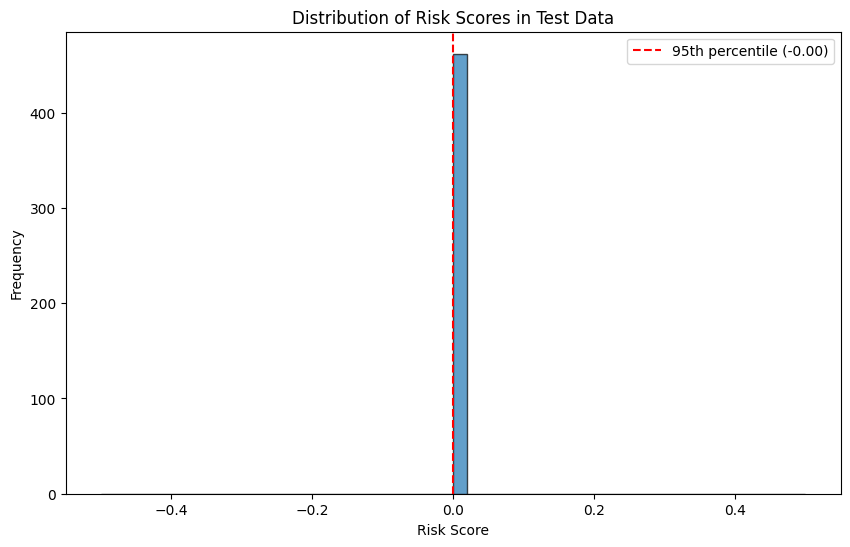


Prediction distribution:
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Class 0 (Normal): 388 predictions
Class 1 (Uncomfortable): 74 predictions


In [57]:
# analysing the risk scores and thresholds
print("\n=== DIAGNOSTIC ANALYSIS ===")

# Get risk scores for all test patients
all_risk_scores = []
for patient_id in test_patients:
    patient_mask = (sequence_to_patient == patient_id)
    if np.any(patient_mask):
        patient_scores = risk_score[patient_mask]
        patient_thresh = patient_thresholds[patient_id]
        max_score = np.max(patient_scores)
        
        print(f"Patient {patient_id}: Max score = {max_score:.3f}, Threshold = {patient_thresh:.3f}, Alerts = {np.sum(patient_scores > patient_thresh)}")
        all_risk_scores.extend(patient_scores)

# Plot the distribution of risk scores
plt.figure(figsize=(10, 6))
plt.hist(risk_score, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(x=np.percentile(risk_score, 95), color='red', linestyle='--', 
            label=f'95th percentile ({np.percentile(risk_score, 95):.2f})')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.title('Distribution of Risk Scores in Test Data')
plt.legend()
plt.show()

# Check what predictions your model is making
print("\nPrediction distribution:")
y_pred_classes = np.argmax(model.predict(X_test), axis=1)
unique, counts = np.unique(y_pred_classes, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls} ({'Normal' if cls==0 else 'Uncomfortable' if cls==1 else 'Sick'}): {count} predictions")

##  Validate alert accuracy

In [58]:
# Define what counts as a true anomaly (e.g., state = 2 for 'sick')
true_anomalies = (y_test == 2)  # True for sick states, False otherwise

# Get the alert predictions from the system
alert_predictions = []
for i in range(len(X_test)):
    patient_id = sequence_to_patient[i]
    risk = risk_score[i]
    threshold = patient_thresholds.get(patient_id, 1.5)
    alert_predictions.append(risk > threshold)

alert_predictions = np.array(alert_predictions)

In [59]:
# ---------------------
# Calculate Key Performance Metrics
# ---------------------

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

print("=== ALERT SYSTEM PERFORMANCE METRICS ===")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(true_anomalies, alert_predictions).ravel()
print(f"True Negatives (Normal, no alert): {tn}")
print(f"False Positives (Normal, alert triggered): {fp}")
print(f"False Negatives (Anomaly, no alert): {fn}")
print(f"True Positives (Anomaly, alert triggered): {tp}")

# Calculate rates
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"\nFalse Positive Rate: {false_positive_rate:.3f}")
print(f"False Negative Rate: {false_negative_rate:.3f}")
print(f"Accuracy: {accuracy:.3f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(true_anomalies, alert_predictions, 
                           target_names=['Normal', 'Anomaly']))

=== ALERT SYSTEM PERFORMANCE METRICS ===
True Negatives (Normal, no alert): 422
False Positives (Normal, alert triggered): 0
False Negatives (Anomaly, no alert): 40
True Positives (Anomaly, alert triggered): 0

False Positive Rate: 0.000
False Negative Rate: 1.000
Accuracy: 0.913

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      1.00      0.95       422
     Anomaly       0.00      0.00      0.00        40

    accuracy                           0.91       462
   macro avg       0.46      0.50      0.48       462
weighted avg       0.83      0.91      0.87       462



C:\Users\anngu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anngu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anngu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

In [60]:
# ---------------------
# Measure Timeliness
# ---------------------

# For true positives, measure how early alerts were triggered
early_detection_times = []

for i in np.where(true_anomalies & alert_predictions)[0]:  # True positives
    patient_id = sequence_to_patient[i]
    
    # Find when the anomaly first started for this patient
    patient_anomaly_indices = np.where((sequence_to_patient == patient_id) & (y_test == 2))[0]
    if len(patient_anomaly_indices) > 0:
        first_anomaly_time = np.min(patient_anomaly_indices)
        alert_time = i
        time_difference = alert_time - first_anomaly_time
        early_detection_times.append(time_difference)

if early_detection_times:
    print(f"\n=== TIMELINESS ANALYSIS ===")
    print(f"Average early detection: {np.mean(early_detection_times):.1f} time steps")
    print(f"Earliest detection: {np.min(early_detection_times)} time steps before anomaly")
    print(f"Latest detection: {np.max(early_detection_times)} time steps after anomaly start")
else:
    print("No true positives for timeliness analysis")

No true positives for timeliness analysis
